Agentic Code Generation with LangGraph and DSPy

onverts a natural-language software request into a structured plan, generated files, iterative LLM review, and a runnable project.

### Importing Libraries and Loading environment variables

In [249]:
from langchain_community.tools import ShellTool
from typing import Optional
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser, JsonOutputParser, StrOutputParser
from langsmith import traceable
from tavily import TavilyClient
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from pprint import pprint
from typing import List
# from tenacity import retry, stop_after_attempt
load_dotenv()  # Load environment variables from .env file


True

### Configure the LangChain and DSPy LLM Backends

In [250]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gptoss",

    base_url="http://127.0.0.1:8000/v1",

    api_key="dummy",

    temperature=0.2,

    max_retries=0,
)

       


In [251]:
import dspy

lm = dspy.LM(
    "openai/gptoss",
    api_base="http://127.0.0.1:8000/v1",
    api_key="dummy",
    temperature=0.2,
    cache=False,
    num_retries=0,
)

dspy.configure(lm=lm)


### Define the Shared LangGraph Workflow State

### Generate the Project Architecture and Dependency-Aware Task Plan

In [252]:
class todo_structure(BaseModel):
    step_number : int = Field(description="like 1, 2, 3")
    task_name : str = Field(description="Name of the task")
    description : str = Field(description="Detailed description of what must be implemented with the technology")
    target_file_or_folder : str = Field(description="agent/example_module.py")
    dependencies : List[int] = Field(default_factory=list)
    is_implemented : bool = Field(default=False)

In [253]:
class Folder_structure(BaseModel):
    agent : dict = Field(description="example_module.py : Description of this file")

In [254]:
class project_structure(BaseModel):
    project_name : str = Field(description="Name of the project")
    architecture_summary : str = Field(description="A concise 1-2 sentence architecture summary")
    folder_structures : List[Folder_structure] = Field(description="structure of folder")
    todo_list : List[todo_structure] = Field(description="step by step procedure for the project")
    

In [255]:
class state(BaseModel):
    query: str = Field(description="The query to be processed by the model.")
    todo_list : Optional[project_structure]  = Field(default={}, description="write the to do list to be done for this task")
    code : Optional[dict] = Field(default = {}, description="The code generated by the model in response to the query.")
    command : Optional[dict] = Field(default = {}, description="The command generated by the model in response to read or write the code.")
    error : Optional[str] = Field(default=None,description="The error casused")
    test_cases : Optional[str] = Field(default = None, description="The test cases generated by the model for the code.")
    current_step : Optional[int] = Field(default=None, description="Current step for executing codes")
    is_implemented : Optional[bool] = Field(default=None, description="entire is implemented or not")


In [259]:
INPUT_DIRECTORY = "agent/"
@traceable
def create_todotask(state_obj : state):
    print("state at create todotask", state_obj)

    template = """
You are an expert software architect and project manager.

Your task is to break down a given project into a highly modular
folder structure and provide a step-by-step to-do list for implementation.
Keep the architecture as simple as possible and separate different modules and connect them properly
Each step should correspond to a module, Python file, or logical component
in an appropriate directory.

Orchestrate the tasks so they can later be used for code generation.

Do exactly what is requested. Do not add unnecessary functionality,
especially deployment-related components unless explicitly requested.

Keep the architecture as simple and short as possible.

Start the project inside the {input_directory} directory.

Return EXCLUSIVELY a valid JSON object.
Do not return markdown.
Do not return ```json.
Do not return explanations outside the JSON.
Do not return comments inside the JSON.

If asked for UI, create in html and css in proper place

include the requirements as well

The response MUST follow this structure:

PROJECT TASK:
{input_query}


{format_instructions}
"""
    output_parser = PydanticOutputParser(pydantic_object=project_structure)

    prompt = PromptTemplate(
        template=template,
        input_variables=['input_query','input_directory'],
        partial_variables={
            'format_instructions': output_parser.get_format_instructions()
        }
    )
    chain = prompt | llm | output_parser
    result = chain.invoke({"input_query" : state_obj.query,'input_directory':INPUT_DIRECTORY})
    state_obj.todo_list = result
    return state_obj



### Select the Next Unfinished Implementation Task

In [260]:
def redirect(state_obj : state):

    todo_list = state_obj.todo_list.todo_list
    

    for ind,todo in enumerate(todo_list):
        if not todo.is_implemented:
            state_obj.current_step = ind
            return state_obj
    state_obj.is_implemented = True
    return state_obj

### Define the DSPy Developer and Code Reviewer Signatures

In [261]:
class transform_code(dspy.Signature):
    """Generate content only for the requested target file."""

    input_task = dspy.InputField(
        desc="Exact task that must be implemented"
    )
    target_file = dspy.InputField(
        desc="Exact file receiving the generated content"
    )
    
    existing_code = dspy.InputField(
        desc="Dependency code for reference only; do not reproduce it"
    )
    current_file_content = dspy.InputField(
        desc="Existing content of the target file, empty for a new file"
    )
    feedback_str = dspy.InputField(
            des = "feedback for previously genearted code to the LLM so that it can generate better"
        )
    current_codeissue = dspy.InputField(
            desc="the current code to be fixed"
        )
    code = dspy.OutputField(
        desc=(
            "Return only the complete content for target_file. "
            "Do not generate other files, file labels, Markdown fences, "
            "or dependency code."
        )
    )


class validate(dspy.Signature):

    given_task : str = dspy.InputField(
        desc = "Input task given"
    )
    input_code : str = dspy.InputField(
        desc = "Exact task that must be implemented"
    )
    reference_code : dict = dspy.InputField(
        desc = "input code depends on these code"
    )
    feedback_score : float = dspy.OutputField(
        desc = "code quality for the input generated code between 0 and 1"
    )
    feedback_str : str = dspy.OutputField(
        desc = "summarised feedback for the generated codes"
    )

Clean Markdown Formatting from Generated Source Code

In [262]:
def remove_markdown_from_code(code:str):
    code = code.strip()

    if not code.startswith("```"):
        return code

    lines = code.splitlines()
    if lines[0].startswith("```"):
        lines = lines[1:]
    if lines[-1].startswith("```"):
        lines = lines[:-1]

    return '\n'.join(lines)

### Generate, Review, and Iteratively Improve Each File

In [263]:

    
@traceable
def implement_code(state_obj:state):

    print(f"current state",state_obj.current_step)
    print(f"current task",state_obj.todo_list.todo_list[state_obj.current_step].task_name)

    
    current_step = state_obj.current_step
    current_task = state_obj.todo_list.todo_list[current_step]
    target_file = current_task.target_file_or_folder

    existing_codesreq = {"step_number_"+str(i) : state_obj.code["step_number_" + str(i)] for i in state_obj.todo_list.todo_list[current_step].dependencies}
    feedback = "no previous code generated"
    current_code = "nothing now"

    validate_code = dspy.ChainOfThought(validate)
    generate_code = dspy.ChainOfThought(transform_code)

    n = 10
    max_score = -1
    best_code = None
    for i in range(1,n+1):
        print(f"______ trial {i} __________")
        response = generate_code(
            input_task=current_task.description,
            target_file=target_file,
            existing_code=existing_codesreq,
            current_file_content="",
            feedback_str = feedback,
            current_codeissue = current_code
        )
        
        current_code = remove_markdown_from_code(response.code)
        validation = validate_code(input_code = current_code, reference_code = existing_codesreq, given_task = current_task.description)
        print(f"validation score {validation.feedback_score}")
        feedback = validation.feedback_str
        # current_code = response.code
        
        if validation.feedback_score >max_score :
            best_code = current_code

        if i<n and validation.feedback_score >=0.8:
            break
    state_obj.code["step_number_" + str(state_obj.todo_list.todo_list[current_step].step_number)] = best_code
    return state_obj



### Write the Accepted Code to the Generated Project Directory

Generated paths and code should be validated and executed only inside a secure sandbox.

In [264]:
@traceable
def implement_command(state_obj:state):

    current_step = state_obj.current_step
    current_task = state_obj.todo_list.todo_list[current_step]
    generated_code = state_obj.code['step_number_' + str(current_task.step_number) ]

    current_file = current_task.target_file_or_folder
    if len(current_file.split('/'))>1:
        folder = '/'.join(current_file.split('/')[:-1])
    else:
        folder = " "
    ShellTool().invoke(f"""mkdir -p {folder} && cat > {current_file} << 'EOF'
{generated_code} """)
    state_obj.todo_list.todo_list[current_step].is_implemented = True


### ### Assemble and Visualize the LangGraph Workflow

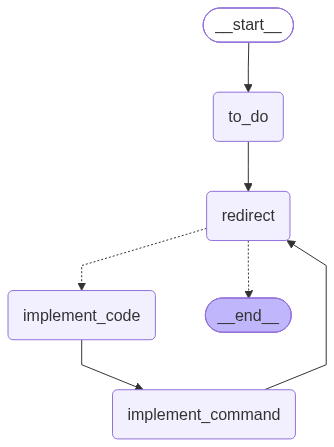

In [265]:
workflow = StateGraph(state)
workflow.add_node("to_do",create_todotask)
workflow.add_node("redirect",redirect)
workflow.add_node("implement_code",implement_code)
workflow.add_node("implement_command",implement_command)

workflow.add_edge(START, "to_do")
workflow.add_edge("to_do","redirect")


def route_to_next_task(state_obj: state):
    if not state_obj.is_implemented:
        return "implement_code"
    return END

workflow.add_conditional_edges(
    "redirect",
    route_to_next_task,
    {
        "implement_code":"implement_code",
        END:END
    }
    
)
workflow.add_edge("implement_code","implement_command")
workflow.add_edge("implement_command","redirect")

agent = workflow.compile()

display(Image(agent.get_graph().draw_mermaid_png()))


### Run the End-to-End Code Generation Demonstration

In [266]:
query1 = "write a code to check if a number is prime or not with web page ui"
query2 = "Build a library management system with modules for books, members, borrowing, and reporting with webpage ui."
query3 = "Create a weather application with separate modules for API access, caching, data processing, and UI properly."
query4 = "Develop an e-commerce backend with authentication, products, cart, orders, and payments."
query5 = "Build a Flask to-do application with routes, services, HTML templates, CSS, and in-memory storage."
agent.invoke({"query":query1})

/Users/jyostnabanik/AI Agents/.agent/lib/python3.14/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `project_structure` - serialized value may not be as expected [field_name='todo_list', input_value={}, input_type=dict])
  return self.__pydantic_serializer__.to_python(


state at create todotask query='write a code to check if a number is prime or not with web page ui' todo_list={} code={} command={} error=None test_cases=None current_step=None is_implemented=None
current state 0
current task Initialize project structure
______ trial 1 __________
validation score 0.96
Executing command:
 mkdir -p agent && cat > agent/ << 'EOF'
--- agent/app.py ---
```python
# app.py
# Minimal Flask application placeholder

from flask import Flask, render_template

app = Flask(__name__)

@app.route("/")
def index():
    return render_template("index.html")

if __name__ == "__main__":
    # Run in debug mode for development
    app.run(host="0.0.0.0", port=5000, debug=True)
```

--- agent/templates/index.html ---
```html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Agent</title>
    <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}">
</head>
<body>
    <h1>Welcome to the Agent</h1>
    <p>This is a placeholder pag

/Users/jyostnabanik/AI Agents/.agent/lib/python3.14/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


validation score 0.95
Executing command:
 mkdir -p agent/templates && cat > agent/templates/index.html << 'EOF'
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Prime Checker</title>
    <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}">
</head>
<body>
    <h1>Prime Number Checker</h1>

    <form action="/check" method="post" id="prime-form">
        <label for="number">Enter a number:</label>
        <input type="number" id="number" name="number" required min="0" step="1">
        <button type="submit">Check</button>
    </form>

    <div id="result" style="margin-top: 20px; font-weight: bold;">
        <!-- Result of the prime check will appear here -->
    </div>
</body>
</html> 
current state 2
current task Add CSS styling
______ trial 1 __________
validation score 0.95
Executing command:
 mkdir -p agent/static && cat > agent/static/style.css << 'EOF'
/* agent/static/style.css */

/* --------------------------------------------

{'query': 'write a code to check if a number is prime or not with web page ui',
 'todo_list': project_structure(project_name='Prime Number Checker Web App', architecture_summary='A minimal Flask web application serving an HTML page with a form; the backend validates the input and returns whether the number is prime.', folder_structures=[Folder_structure(agent={'app.py': 'Flask application handling routes and prime checking logic', 'templates/index.html': 'HTML page with input form and result display', 'static/style.css': 'CSS styling for the web page', 'requirements.txt': 'Project dependencies (Flask)'})], todo_list=[todo_structure(step_number=1, task_name='Initialize project structure', description='Create the agent directory with subfolders templates and static, and placeholder files app.py, templates/index.html, static/style.css, requirements.txt.', target_file_or_folder='agent/', dependencies=[], is_implemented=True), todo_structure(step_number=2, task_name='Create HTML UI', descri